In [ ]:
#wap to build basic gan network to generate handwritten digits

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [ ]:



(x_train, _), (_, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1)


In [ ]:

# Flatten images for discriminator
x_train_flat = x_train.reshape(x_train.shape[0], -1)


discriminator = Sequential([
    Dense(512, input_dim=784),
    LeakyReLU(0.2),
    Dense(256),
    LeakyReLU(0.2),
    Dense(1, activation='sigmoid')
])



discriminator.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002, 0.5),
    metrics=['accuracy'])





In [ ]:
latent_dim = 100

generator = Sequential([
    Dense(256, input_dim=latent_dim),
    LeakyReLU(0.2),
    Dense(512),
    LeakyReLU(0.2),
    Dense(784, activation='sigmoid'),
    Reshape((28, 28, 1))
])



discriminator.trainable = False

gan = Sequential([
    generator,
    Flatten(),
    discriminator
])

gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002, 0.5)
)




In [ ]:
epochs = 10000
batch_size = 64

for epoch in range(epochs):

    # Train Discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]
    real_images = real_images.reshape(batch_size, -1)

    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_images = generator.predict(noise, verbose=0)
    fake_images = fake_images.reshape(batch_size, -1)

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_images, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    valid_labels = np.ones((batch_size, 1))

    g_loss = gan.train_on_batch(noise, valid_labels)

    # Print progress
    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss[0]:.4f} | G Loss: {g_loss:.4f}")




Epoch 0 | D Loss: 4.6451 | G Loss: 0.0036
Epoch 1000 | D Loss: 4.7418 | G Loss: 0.0029
Epoch 2000 | D Loss: 4.8132 | G Loss: 0.0024
Epoch 3000 | D Loss: 4.8693 | G Loss: 0.0021
Epoch 4000 | D Loss: 4.9138 | G Loss: 0.0018
Epoch 5000 | D Loss: 4.9496 | G Loss: 0.0016
Epoch 6000 | D Loss: 4.9794 | G Loss: 0.0015
Epoch 7000 | D Loss: 5.0046 | G Loss: 0.0014
Epoch 8000 | D Loss: 5.0277 | G Loss: 0.0013
Epoch 9000 | D Loss: 5.0478 | G Loss: 0.0012


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


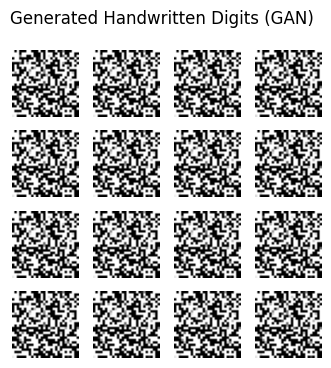

In [ ]:
noise = np.random.normal(0, 1, (16, latent_dim))
generated_images = generator.predict(noise)

plt.figure(figsize=(4, 4))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Handwritten Digits (GAN)")
plt.show()